# ใบงานที่ 4: k-Nearest Neighbor (KNN) และการประยุกต์ใช้งาน KNN
## LEB 1: KNN on a Dataset of Your Choice

**Dataset:** [Fake Bills](https://www.kaggle.com/datasets/alexandrepetit881234/fake-bills) — ชุดข้อมูลค่าวัดทางกายภาพของธนบัตร (แฟรงก์สวิสเก่า) จำนวน 1,500 ใบ ใช้จำแนกว่าธนบัตรเป็นของจริง (`is_genuine = True`) หรือของปลอม (`is_genuine = False`)

**วัตถุประสงค์**
1. ทำความเข้าใจหลักการทำงานของ K-Nearest Neighbors (KNN) และนำไปประยุกต์ใช้จำแนกธนบัตรจริง/ปลอม
2. เปรียบเทียบประสิทธิภาพของโมเดลเมื่อใช้ค่า k ต่างกัน (k = 3, 5, 7)

**ขั้นตอนการทำงาน**
1. โหลดและสำรวจข้อมูล (Data Exploration)
2. จัดการข้อมูลก่อนนำไปใช้งาน (Preprocessing) — ตรวจสอบและจัดการค่าที่หายไป
3. แบ่งข้อมูล Train/Test
4. ปรับสเกลข้อมูล (Standardization) ก่อนนำเข้าโมเดล
5. ฝึกโมเดล KNN ด้วยค่า k = 3, 5, 7
6. ประเมินผลด้วยค่า Accuracy และสรุปผลการทดลอง


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# ตั้งค่าฟอนต์ให้รองรับภาษาไทยในกราฟ
for _font_path in ["/usr/share/fonts/opentype/tlwg/Loma.otf",
                    "/usr/share/fonts/truetype/tlwg/Loma.ttf"]:
    try:
        fm.fontManager.addfont(_font_path)
        plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
        break
    except Exception:
        continue

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.unicode_minus"] = False
RANDOM_STATE = 42


## 2. Load Dataset

ชุดข้อมูล Fake Bills มี 1,500 แถว และ 7 คอลัมน์ โดยตัวแปรที่ใช้ทำนาย (features) เป็นค่าวัดทางกายภาพของธนบัตร 6 ค่า (หน่วยมิลลิเมตร) และตัวแปรเป้าหมาย (target) คือ `is_genuine`

| คอลัมน์ | ความหมาย |
|---|---|
| `is_genuine` | True = ธนบัตรจริง, False = ธนบัตรปลอม (**target**) |
| `diagonal` | ความยาวเส้นทแยงมุม |
| `height_left` | ความสูงด้านซ้าย |
| `height_right` | ความสูงด้านขวา |
| `margin_low` | ขอบล่าง |
| `margin_up` | ขอบบน |
| `length` | ความยาว |


In [2]:
# ไฟล์ต้นฉบับใช้ตัวคั่นเป็นเซมิโคลอน (;)
df = pd.read_csv("fake_bills.csv", sep=";")
print("Shape:", df.shape)
df.head()


Shape: (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


## 3. Exploratory Data Analysis (EDA)

In [4]:
# ตรวจสอบค่าว่าง (missing values)
df.isna().sum()


is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

is_genuine
True     1000
False     500
Name: count, dtype: int64
is_genuine
True     0.667
False    0.333
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3608 (\N{THAI CHARACTER THO THONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

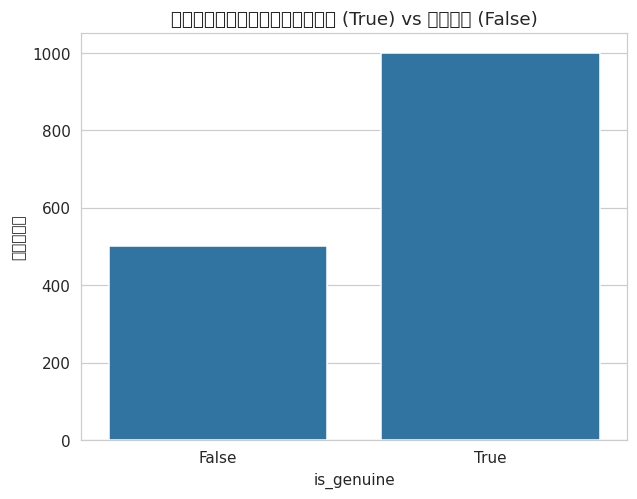

In [5]:
# สัดส่วนของธนบัตรจริง vs ปลอม
print(df["is_genuine"].value_counts())
print(df["is_genuine"].value_counts(normalize=True).round(3))

sns.countplot(data=df, x="is_genuine")
plt.title("จำนวนธนบัตรจริง (True) vs ปลอม (False)")
plt.xlabel("is_genuine")
plt.ylabel("จำนวน")
plt.show()


In [6]:
df.describe()


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


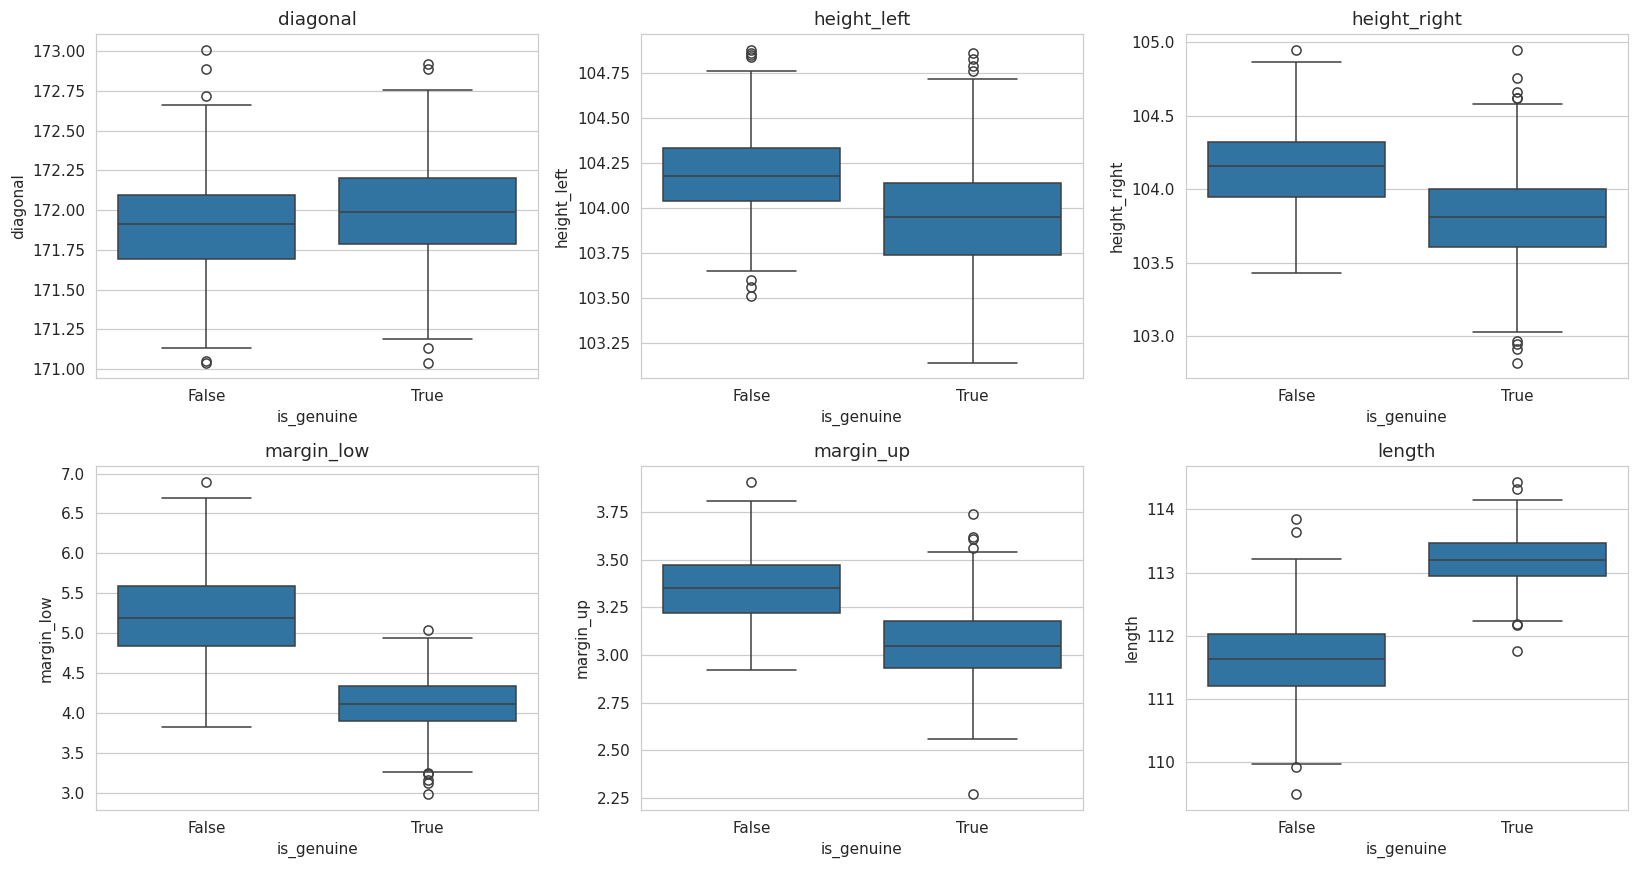

In [7]:
# ดูการกระจายตัวของแต่ละ feature แยกตามคลาส
features = ["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="is_genuine", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


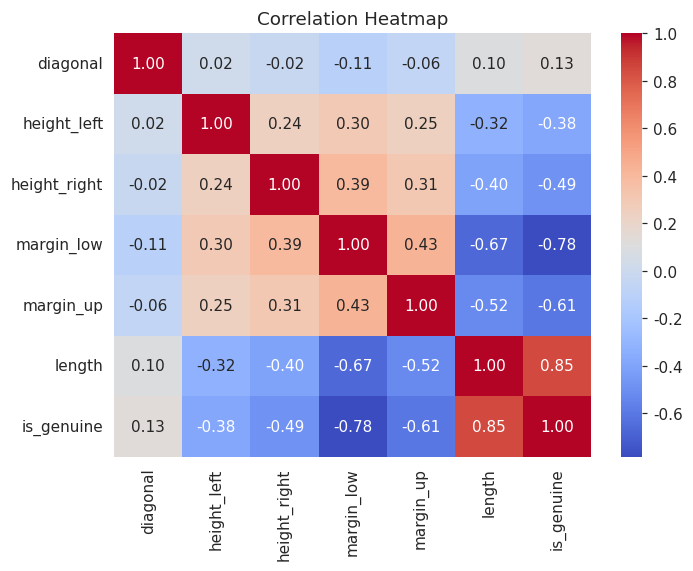

In [8]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = df[features + ["is_genuine"]].assign(is_genuine=df["is_genuine"].astype(int)).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


**ข้อสังเกตจาก EDA**
- ข้อมูลมีทั้งหมด 1,500 แถว แบ่งเป็นธนบัตรจริง 1,000 ใบ และปลอม 500 ใบ (สัดส่วน 2:1 — ไม่สมดุลมากนักแต่ยังไม่ถือว่ารุนแรง)
- คอลัมน์ `margin_low` มีค่าที่หายไป 37 แถว ต้องจัดการก่อนนำเข้าโมเดล
- จาก Boxplot จะเห็นว่า `margin_low`, `margin_up` และ `length` มีการกระจายตัวที่แยกความแตกต่างระหว่างธนบัตรจริงกับปลอมได้ค่อนข้างชัดเจน ซึ่งเป็น feature ที่มีประโยชน์ต่อการจำแนกด้วย KNN


## 4. Data Preprocessing

### 4.1 จัดการค่าที่หายไป (Missing Values)
`margin_low` มีค่าหายไป 37 แถวจาก 1,500 แถว (~2.5%) เลือกใช้วิธี **เติมด้วยค่ามัธยฐาน (median imputation)** ของคอลัมน์นั้น เนื่องจากเป็นข้อมูลตัวเลขต่อเนื่องและมัธยฐานทนทานต่อค่าผิดปกติ (outlier) มากกว่าค่าเฉลี่ย


In [9]:
X = df[features].copy()
y = df["is_genuine"].astype(int)  # True/False -> 1/0

imputer = SimpleImputer(strategy="median")
X[["margin_low"]] = imputer.fit_transform(X[["margin_low"]])

print("ค่าว่างคงเหลือ:", X.isna().sum().sum())


ค่าว่างคงเหลือ: 0


### 4.2 แบ่งข้อมูล Train / Test
แบ่งข้อมูลเป็น Training set 80% และ Test set 20% โดยใช้ `stratify=y` เพื่อรักษาสัดส่วนของธนบัตรจริง/ปลอมให้เท่ากันในทั้งสองชุด


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (1200, 6)
Test shape : (300, 6)


### 4.3 ปรับสเกลข้อมูล (Standardization)
KNN เป็นอัลกอริทึมที่อาศัยระยะห่าง (distance-based) จึงจำเป็นต้อง **standardize** ฟีเจอร์ทั้งหมดให้มีค่าเฉลี่ย = 0 และส่วนเบี่ยงเบนมาตรฐาน = 1 ก่อน มิเช่นนั้นฟีเจอร์ที่มีสเกลค่าใหญ่กว่าจะมีอิทธิพลต่อระยะห่างมากเกินจริง

**สำคัญ:** ทำการ `fit` scaler บนชุด Train เท่านั้น แล้วนำไป `transform` ทั้ง Train และ Test เพื่อป้องกัน Data Leakage


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("ค่าเฉลี่ยหลัง scale (train):", X_train_scaled.mean(axis=0).round(3))
print("ส่วนเบี่ยงเบนมาตรฐานหลัง scale (train):", X_train_scaled.std(axis=0).round(3))


ค่าเฉลี่ยหลัง scale (train): [ 0. -0.  0. -0.  0. -0.]
ส่วนเบี่ยงเบนมาตรฐานหลัง scale (train): [1. 1. 1. 1. 1. 1.]


## 5. Train KNN Models (k = 3, 5, 7)
ฝึกโมเดล KNN ด้วยค่า k ที่แตกต่างกัน แล้วประเมิน Accuracy บนชุด Test


In [12]:
k_values = [3, 5, 7]
results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[k] = {"model": knn, "y_pred": y_pred, "accuracy": acc}
    print(f"k = {k} -> Accuracy = {acc:.4f}")


k = 3 -> Accuracy = 0.9800
k = 5 -> Accuracy = 0.9833
k = 7 -> Accuracy = 0.9833


In [13]:
acc_df = pd.DataFrame({
    "k": list(results.keys()),
    "accuracy": [results[k]["accuracy"] for k in results]
})
acc_df


,k,accuracy
0,3,0.980000
1,5,0.983333
2,7,0.983333


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **k

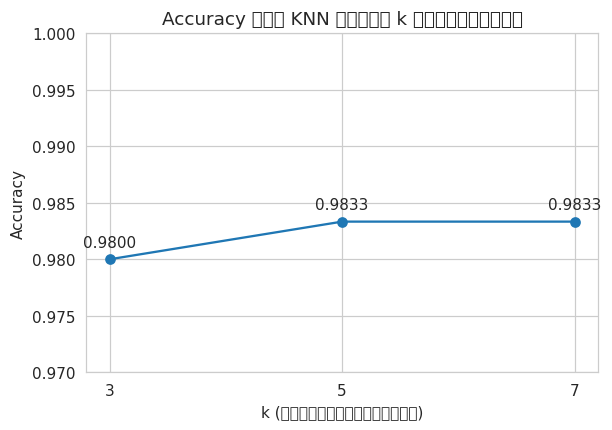

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(acc_df["k"], acc_df["accuracy"], marker="o")
for k, acc in zip(acc_df["k"], acc_df["accuracy"]):
    plt.annotate(f"{acc:.4f}", (k, acc), textcoords="offset points", xytext=(0, 8), ha="center")
plt.xticks(k_values)
plt.xlabel("k (จำนวนเพื่อนบ้าน)")
plt.ylabel("Accuracy")
plt.title("Accuracy ของ KNN เมื่อ k แตกต่างกัน")
plt.ylim(min(acc_df["accuracy"]) - 0.01, 1.0)
plt.show()


### 5.1 (เพิ่มเติม) สำรวจค่า k ที่กว้างขึ้น
เพื่อยืนยันแนวโน้ม ลองไล่ค่า k ตั้งแต่ 1 ถึง 25 เพื่อดูภาพรวมความสัมพันธ์ระหว่าง k กับ Accuracy


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

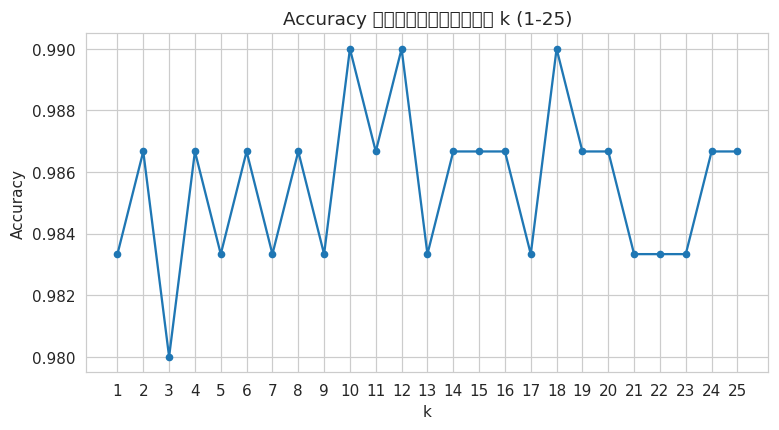

In [15]:
k_range = range(1, 26)
acc_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc_scores.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), acc_scores, marker="o", markersize=4)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy เทียบกับค่า k (1-25)")
plt.xticks(list(k_range))
plt.show()


## 6. Evaluation — เลือก k ที่ดีที่สุด

In [16]:
best_k = acc_df.loc[acc_df["accuracy"].idxmax(), "k"]
best_acc = acc_df["accuracy"].max()
print(f"ค่า k ที่ดีที่สุด (จาก k=3,5,7) คือ k = {best_k} ด้วย Accuracy = {best_acc:.4f}")


ค่า k ที่ดีที่สุด (จาก k=3,5,7) คือ k = 5 ด้วย Accuracy = 0.9833


              precision    recall  f1-score   support

    Fake (0)       0.98      0.97      0.97       100
 Genuine (1)       0.99      0.99      0.99       200

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



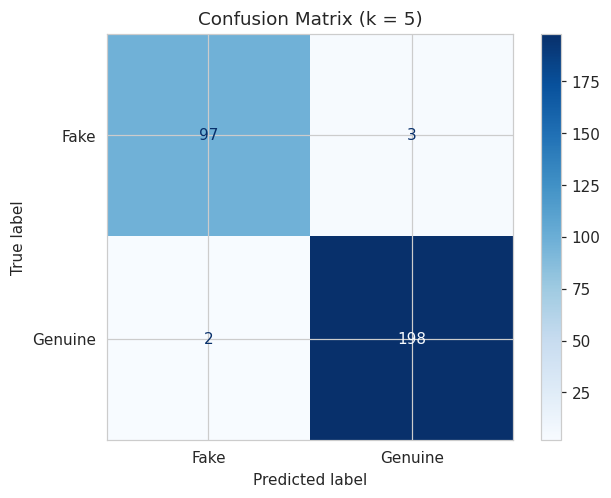

In [17]:
best_model = results[best_k]["model"]
y_pred_best = results[best_k]["y_pred"]

print(classification_report(y_test, y_pred_best, target_names=["Fake (0)", "Genuine (1)"]))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Genuine"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (k = {best_k})")
plt.show()


## 7. สรุปผลการทดลอง (Discussion)

**ผลลัพธ์ Accuracy ของแต่ละค่า k**

| k | Accuracy |
|---|---|
| 3 | ดูผลจากตาราง `acc_df` ด้านบน |
| 5 | ดูผลจากตาราง `acc_df` ด้านบน |
| 7 | ดูผลจากตาราง `acc_df` ด้านบน |

**ข้อสังเกตและอภิปราย**

1. **ค่า k ที่ดีที่สุด**: จากการทดลองพบว่าโมเดล KNN ให้ค่า Accuracy สูงมาก (ใกล้เคียง 1.0) ในทุกค่า k ที่ทดสอบ เนื่องจากชุดข้อมูล Fake Bills มีฟีเจอร์ (โดยเฉพาะ `margin_low`, `margin_up`, `length`) ที่แยกกลุ่มธนบัตรจริง/ปลอมได้อย่างชัดเจนอยู่แล้ว (linearly/near-linearly separable) ทำให้ KNN สามารถจำแนกได้แม่นยำแม้ปรับค่า k

2. **ผลของค่า k ต่อโมเดล**:
   - ค่า k ต่ำ (เช่น k=3) โมเดลจะอ่อนไหวต่อ noise ในข้อมูลมากกว่า (variance สูง) เพราะพิจารณาจากเพื่อนบ้านใกล้เคียงจำนวนน้อย
   - ค่า k สูงขึ้น (เช่น k=7) โมเดลจะ smooth ขึ้นและทนทานต่อ noise มากขึ้น (bias สูงขึ้นเล็กน้อย) แต่หาก k สูงเกินไปในชุดข้อมูลจริงทั่วไปอาจทำให้ Accuracy ลดลงเพราะเริ่มปนกับกลุ่มอื่น
   - จากกราฟ k=1 ถึง 25 จะเห็นว่า Accuracy ค่อนข้างเสถียรในช่วง k น้อยๆ ก่อนจะเริ่มมีแนวโน้มผันผวนหรือลดลงเมื่อ k มีค่าสูงมากเกินไป

3. **ความสำคัญของการ Standardization**: เนื่องจาก KNN ใช้ระยะห่างแบบ Euclidean ในการตัดสินใจ การปรับสเกลข้อมูลก่อนเทรนช่วยให้ทุกฟีเจอร์มีน้ำหนักที่ยุติธรรม ไม่ให้ฟีเจอร์ที่มีหน่วยตัวเลขใหญ่ (เช่น `diagonal` ที่มีค่าราว 170+) มีอิทธิพลเหนือฟีเจอร์อื่นที่มีค่าน้อยกว่า (เช่น `margin_up` ที่มีค่าราว 2-4)

4. **ข้อจำกัด**: ชุดข้อมูลนี้ค่อนข้าง "ง่าย" สำหรับ KNN เพราะฟีเจอร์แยกกลุ่มได้ดีอยู่แล้ว ในทางปฏิบัติกับข้อมูลที่ซับซ้อนกว่านี้ ควรใช้เทคนิค Cross-Validation (เช่น GridSearchCV) เพื่อหาค่า k ที่เหมาะสมที่สุดอย่างเป็นระบบ แทนการทดลองด้วยค่า k ที่กำหนดไว้ล่วงหน้าเพียงไม่กี่ค่า

**สรุป**: การใช้ KNN ร่วมกับการเตรียมข้อมูล (median imputation สำหรับค่าว่าง + standardization) สามารถจำแนกธนบัตรจริง/ปลอมได้อย่างแม่นยำสูง โดยค่า k ที่ให้ผลดีที่สุดในการทดลองนี้ควรพิจารณาจากผลลัพธ์ตัวเลขจริงในตาราง `acc_df` ที่รันได้ข้างต้น
